# 1. Import Library

In [11]:
import torch
from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch.optim as optim

## Read Dataset

In [4]:
# Fetch the MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
assert mnist is not None, "Data and target are not found"

# Only use 20% of data
num_of_samples = mnist.data.shape[0] // 5

X_temp = mnist.data[:num_of_samples]
y_temp = mnist.target[:num_of_samples]

# Rescale to [0, 1.0]
X_temp = X_temp / 255
X_temp = X_temp.reshape(-1, 28, 28)

# Split into training and test set
X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, test_size=0.2, stratify=y_temp)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((11200, 28, 28), (2800, 28, 28), (11200,), (2800,))

## Visualize data

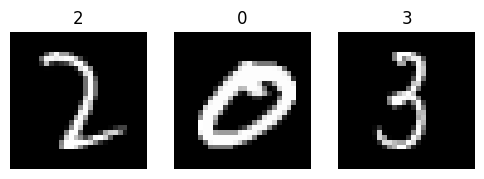

In [5]:
plt.figure(figsize=(6, 2))

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis(False)

plt.show()

## Prepare train loader

In [14]:
from src import get_data_loader

train_loader = get_data_loader(train_data=X_train, batch_size=32)
X_loader = get_data_loader(train_data=X_test, batch_size=32)

train_loader

# 2. Training model

In [19]:
from src import CNNAutoencoder, ModelState, PersistenceLoss
from torch.nn import MSELoss

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

torch.manual_seed(30)
learning_rate = 0.02

model = CNNAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

mse_loss = MSELoss()
persistence_loss = PersistenceLoss()

model_state = ModelState(model, model_name="CNN_seed30", loss_description=["MSE", "TopoLoss"], learning_rate=learning_rate, seed=30, optimizer="Adam")
model_state.log()

--------------------------------------------------
model: CNNAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(7, 7), stride=(1, 1))
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(7, 7), stride=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)
model_name: CNN_seed30
args: {'learning_rate': 0.02, 'seed': 30, 'optimizer': 'Adam'}
loss_history: []
loss_description: ['MSE', 'TopoLoss']
--------------------------------------------------


In [30]:
from tqdm import tqdm

num_epochs = 20

PH_LOSS_SCALE = 0.2

# for epoch in tqdm(range(num_epochs), desc="Epochs"):
model.train()
mse_acc_loss =  0
p_acc_loss = 0
for batch in tqdm(train_loader, desc="Training"):        
    batch = batch.unsqueeze(1)
    input = batch.to(device)
    x_en = model.encode(input)
    output = model.decode(x_en)

    optimizer.zero_grad()

    # Computing MSE loss
    loss = mse_loss(output, input)
    loss.backward(retain_graph=True)
    mse_acc_loss += loss

    # Computing persistence loss
    p_loss = persistence_loss(input, x_en) * PH_LOSS_SCALE
    # p_loss.backward()
    # p_acc_loss += p_loss
    
    # print(f"MSE Loss: {loss} - Persistence Loss: {p_loss}")
    
    optimizer.step()

loss = mse_acc_loss.detach().cpu().numpy() / len(train_loader)
p_loss = p_acc_loss.detach().cpu().numpy() / len(train_loader)

print(f"MSE Loss: {loss} - Persistence Loss: {p_loss}")

model_state.loss_record([loss, p_loss])

print("Training complete ! Saving model...")
# torch.save(model.state_dict(), "topo_ae.pt")

Training:   0%|          | 1/350 [00:01<09:21,  1.61s/it]

MSE Loss: 0.09795123338699341 - Persistence Loss: nan


Training:   1%|          | 2/350 [00:03<09:14,  1.59s/it]

MSE Loss: 0.09591253846883774 - Persistence Loss: nan


Training:   1%|          | 3/350 [00:04<09:18,  1.61s/it]

...

MSE Loss: 0.09561574459075928 - Persistence Loss: nan


Training:   4%|▎         | 13/350 [00:21<09:10,  1.63s/it]

MSE Loss: 0.09790074080228806 - Persistence Loss: nan


Training:   4%|▎         | 13/350 [00:22<09:47,  1.74s/it]


KeyboardInterrupt: 